# Análisis Exploratorio de Datos


## Contexto del Problema de Negocio

En el escenario comercial actual, entender el comportamiento del consumidor y anticipar la pérdida de clientes es un factor crítico para la rentabilidad de la empresa. Este proyecto aborda un problema de negocio real enfocado en la gestión de relaciones con el cliente (CRM) y la predicción de abandono (Churn).

Para resolver esto mediante Machine Learning, contamos con una base de datos histórica (dataset_clientes.csv) que registra variables demográficas, financieras y de comportamiento de los usuarios, incluyendo si el cliente dejó la empresa o no

## Estructura del Análisis Visual

A continuación, se presentan las estadísticas descriptivas y las visualizaciones gráficas (histogramas, diagramas de caja y gráficos de barras) diseñadas específicamente para mapear y evidenciar la "mugre" o ruido que contienen los datos en su estado bruto. Este análisis servirá como justificación técnica para el posterior proceso de preprocesamiento y limpieza de datos.

### 1. Carga de datos

In [ ]:
!wget https://raw.githubusercontent.com/FIJI-1919/REPOSITORIO_TRABAJO_GRUPAL_EV1/refs/heads/main/data/dataset_clientes.csv

--2026-05-25 16:05:46--  https://raw.githubusercontent.com/FIJI-1919/REPOSITORIO_TRABAJO_GRUPAL_EV1/refs/heads/main/data/dataset_clientes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3282843 (3.1M) [text/plain]
Saving to: ‘dataset_clientes.csv’

dataset_clientes.cs 100%[===================>]   3.13M  --.-KB/s    in 0.07s   

2026-05-25 16:05:47 (44.2 MB/s) - ‘dataset_clientes.csv’ saved [3282843/3282843]



In [ ]:
data = pd.read_csv('dataset_clientes.csv')

### 2. Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Calidad de datos

In [ ]:
print(f"Los datos en el csv son: {data.shape}")

Los datos en el csv son: (20400, 22)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

In [ ]:
data.head(6)

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1
5,6,2020-05-14,76,Masculino,Centro,Divorciado,8.247810e+05,718394.747332,1.828219e+06,719.877986,...,294,Bajo,Basico,2,1,App,Sabado,17,9942,0


In [ ]:
data.shape

(20400, 22)

###Duplicados


In [ ]:
duplicados_totales = data.duplicated().sum()
print(f"Filas duplicadas: {duplicados_totales}")

Filas duplicadas: 400


In [ ]:
duplicados_por_id = data['id_cliente'].duplicated().sum()
print(f"Filas duplicadas por id: {duplicados_por_id}")

Filas duplicadas por id: 400


### Valores Nulos

In [ ]:
nulos = data.isnull().sum()
pct   = (nulos / len(data) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
print("--- Columnas con valores nulos ---")
display(tabla_nulos[tabla_nulos['Nulos'] > 0])

--- Columnas con valores nulos ---


,Nulos,Porcentaje (%)
ingreso_mensual,1021,5.00
gasto_mensual,1025,5.02
score_crediticio,1021,5.00


### Valores negativos en variables Financieras

In [ ]:
columnas_financieras = ['ingreso_mensual', 'gasto_mensual', 'deuda_total']
print("Valores negativos por columna:")
for col in columnas_financieras:
    n = (data[col] < 0).sum()
    print(f"  {col}: {n}")

Valores negativos por columna:
  ingreso_mensual: 11
  gasto_mensual: 68
  deuda_total: 143


### Valores Atipicos


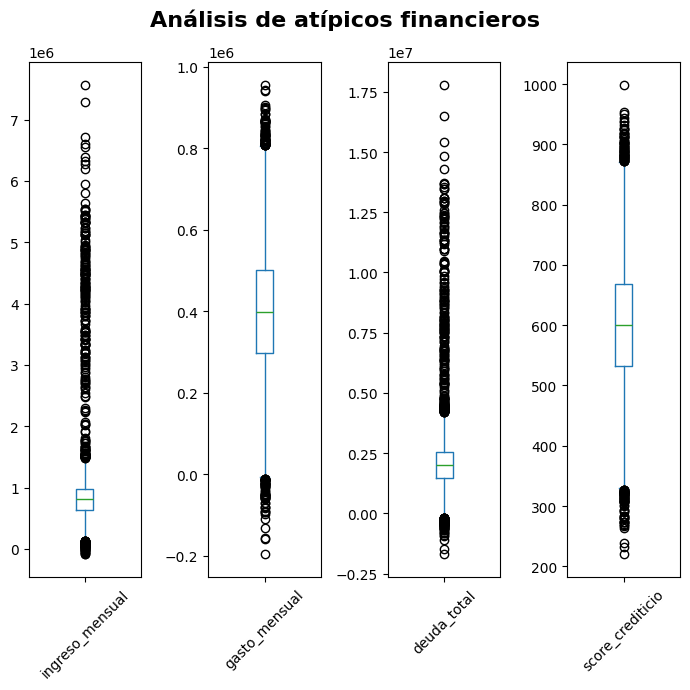

In [30]:
revision_atipicos_fin = ['ingreso_mensual', 'gasto_mensual', 'deuda_total',	'score_crediticio']
fig, axes = plt.subplots(1, 4, figsize=(18,6))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos_fin):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos financieros", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()
fig.savefig('revision_atipicos_fin.png')

## 4. Distribución y Balance de clases

### Variable objetivo: Abandono

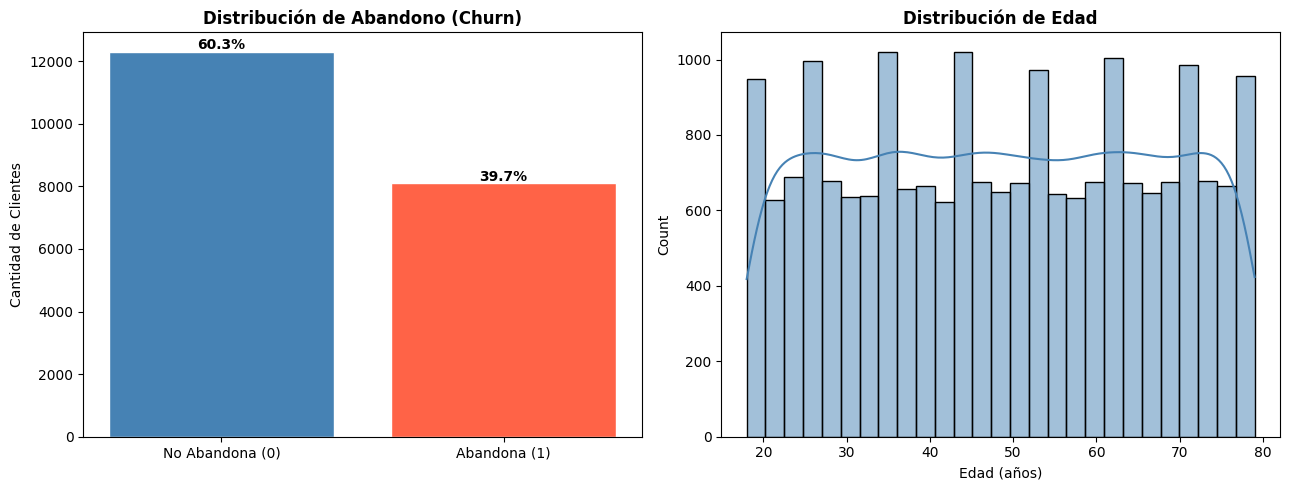

Tasa de abandono: 39.68%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteo
conteo = data['abandono'].value_counts()
bars = axes[0].bar(['No Abandona (0)', 'Abandona (1)'], conteo.values,
                   color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val/len(data)*100:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Distribución de Abandono (Churn)', fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')

# Distribución de edad
sns.histplot(data['edad'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribución de Edad', fontweight='bold')
axes[1].set_xlabel('Edad (años)')

plt.tight_layout()
plt.show()

print(f"Tasa de abandono: {data['abandono'].mean():.2%}")

### Distribución Variables Financieras Claves

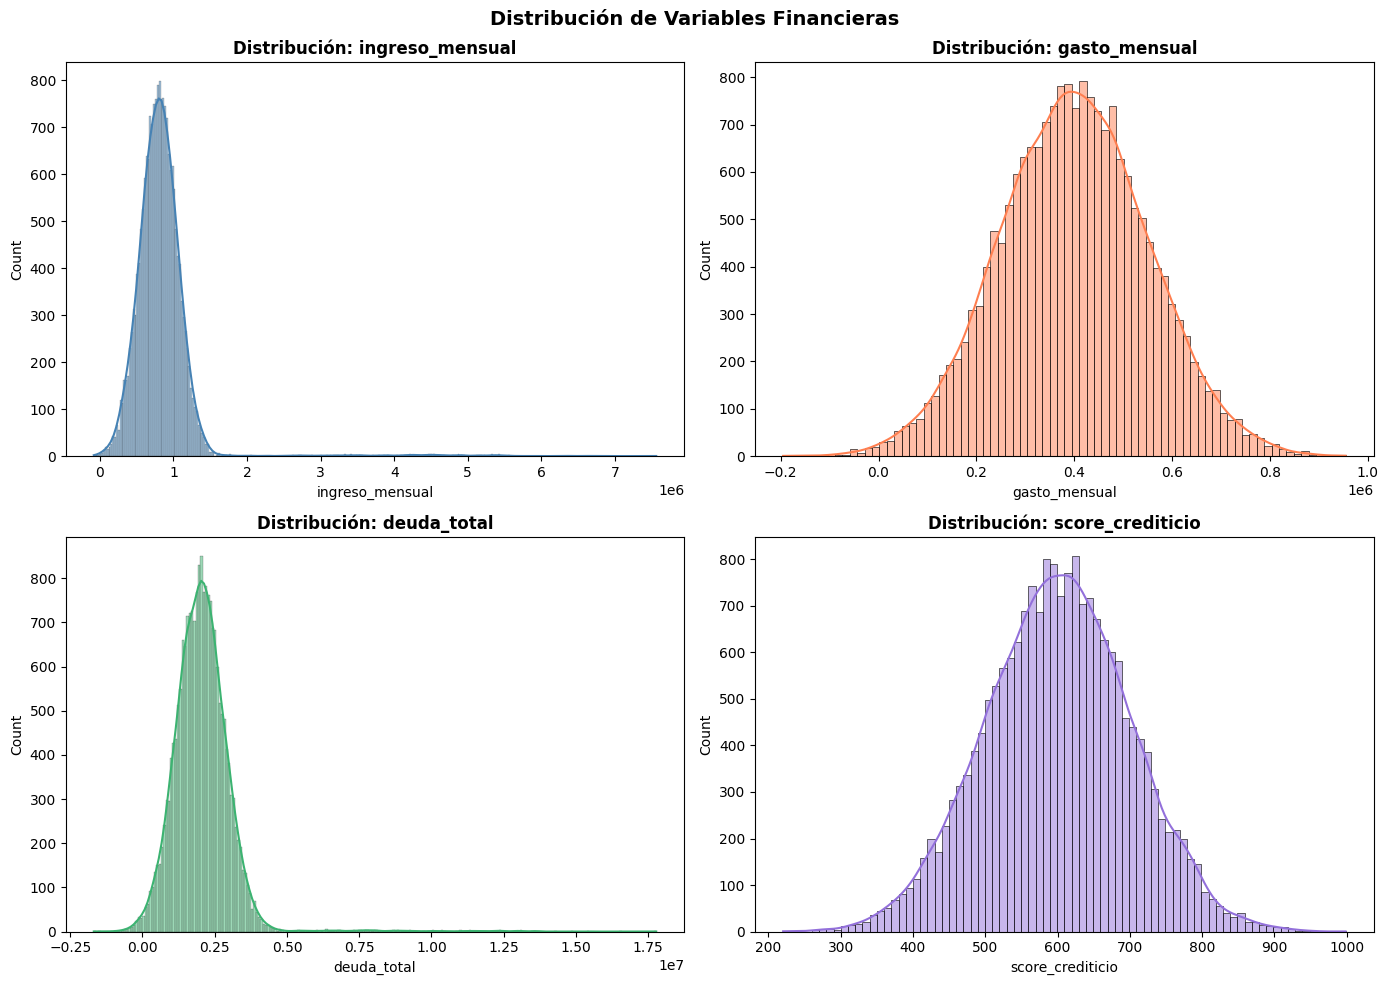

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
variables = ['ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio']
colores   = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for ax, col, color in zip(axes.flatten(), variables, colores):
    sns.histplot(data[col].dropna(), kde=True, color=color, ax=ax)
    ax.set_title(f'Distribución: {col}', fontweight='bold')

plt.suptitle("Distribución de Variables Financieras", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Analisis Bivariado

Variables numericas vs abandono

/tmp/ipykernel_1102/2107082301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='abandono', y=col, data=data, ax=ax, palette='Set2')
/tmp/ipykernel_1102/2107082301.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Abandona', 'Abandona'])
/tmp/ipykernel_1102/2107082301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='abandono', y=col, data=data, ax=ax, palette='Set2')
/tmp/ipykernel_1102/2107082301.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Abandona', 'Aban

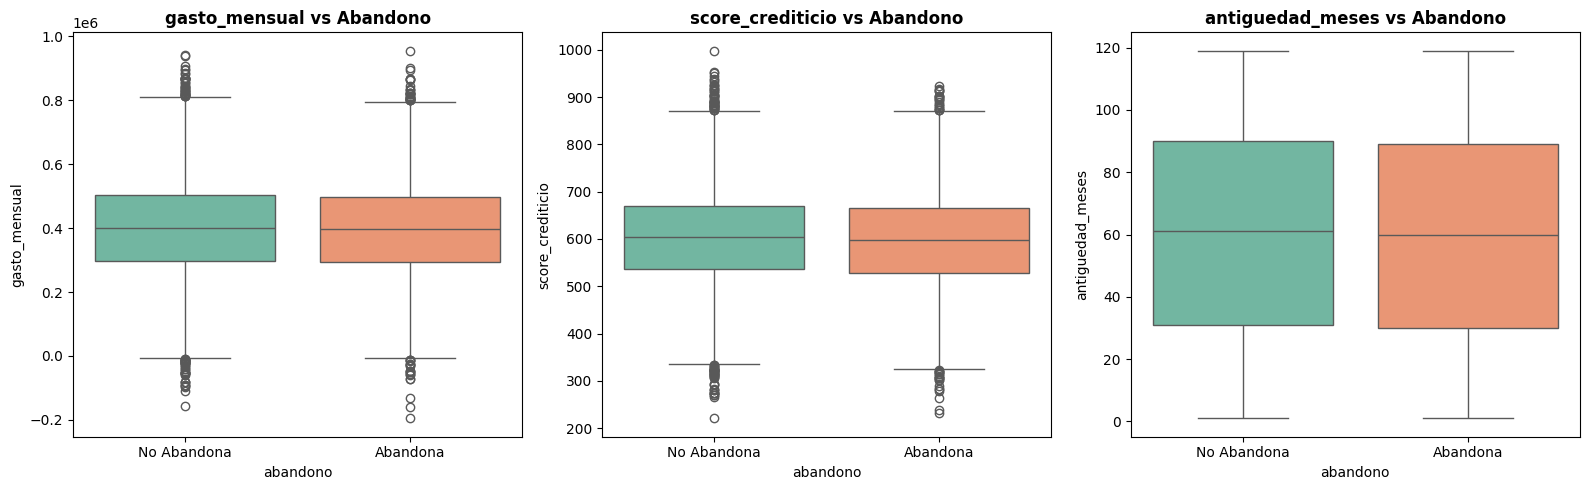

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['gasto_mensual', 'score_crediticio', 'antiguedad_meses']):
    sns.boxplot(x='abandono', y=col, data=data, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Abandono', fontweight='bold')
    ax.set_xticklabels(['No Abandona', 'Abandona'])

plt.tight_layout()
plt.show()

### Variables categoricas vs abandono

/tmp/ipykernel_1102/638561322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='abandono', data=data, ax=ax,
/tmp/ipykernel_1102/638561322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='abandono', data=data, ax=ax,
/tmp/ipykernel_1102/638561322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='abandono', data=data, ax=ax,
/tmp/ipykernel_1102/638561322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

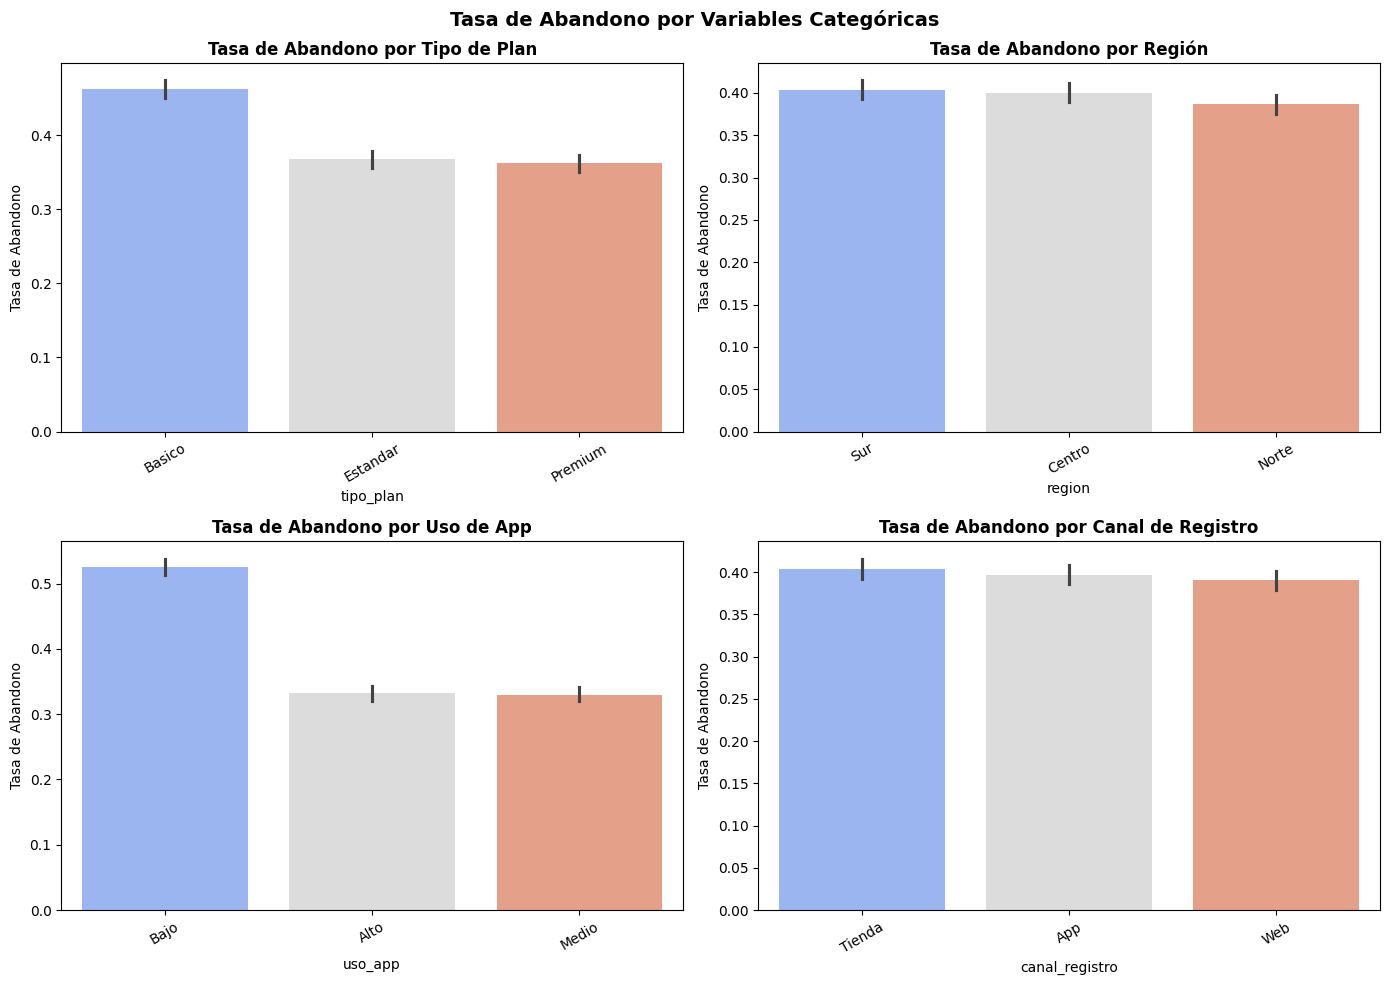

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables_cat = [('tipo_plan', 'Tipo de Plan'),
            ('region',    'Región'),
            ('uso_app',   'Uso de App'),
            ('canal_registro', 'Canal de Registro')]

for ax, (col, titulo) in zip(axes.flatten(), variables_cat):
    orden = data.groupby(col)['abandono'].mean().sort_values(ascending=False).index
    sns.barplot(x=col, y='abandono', data=data, ax=ax,
                order=orden, palette='coolwarm')
    ax.set_title(f'Tasa de Abandono por {titulo}', fontweight='bold')
    ax.set_ylabel('Tasa de Abandono')
    ax.tick_params(axis='x', labelrotation=30)

plt.suptitle("Tasa de Abandono por Variables Categóricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlación de variables numericas

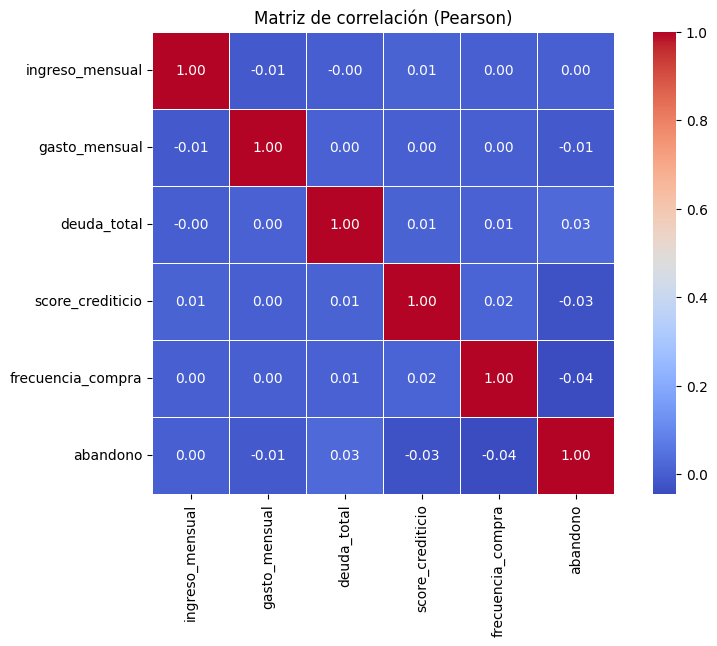

In [41]:
columns_corr = [
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "frecuencia_compra",
    "abandono"
]

corr_pearson = data[columns_corr].corr(method="pearson")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación (Pearson)")
plt.show()

## 7. Conclusiones

Tras realizar el analisis exploratorio inicial y generar visualizaciones de las variables originales, se detectan multiples anomalias y problemas de calidad de datos, detección de duplicados, valores negativos, valores nulos, desbalance de clases (40% de abandono), existe la variable más correlacionada que es ultima compra días y se detectan outliers